# 10 — GPU streaming rewrite validation

Validates the bounded-memory streaming rewrite of the GPU BubbleMaster integrator
(`cpp/bubblemaster/src/gpu_integrator.cu` — see `AI_HANDOFF.md`'s "Planned
minimal-memory GPU rewrite") against the existing reference GPU spectra, before
trusting it for new large-gamma (32, 64) scans.

Reuses the same 5 pair-collision-gamma setups already used for the locked GPU
Filon parameters (`--param 128 --filon-panels-per-osc 40`), at
`data/adaptive_scan_lb0.84_gs1-3.2_kR1-100_wp20/setups/`
(gamma_ij = 1, 2.75, 4.5, 6.25, 8). Reference spectra already exist at
`.../gpu_ppw_scan/ppw40/`, computed with the pre-rewrite (non-streaming) binary.

**Setups are reused, not regenerated** — an identical setup file is the only way
to guarantee a bit-for-bit-comparable input between the old and new binaries.

**Workflow**
1. Run **Section 1** to load the existing manifest.
2. Run **Section 2** to generate the phase-1 SLURM script (repeat the 5 sets once,
   at the default `--s-batch-size`). Submit it and wait for it to finish.
3. Run **Section 4** to load and compare phase-1 results against the `ppw40`
   reference. Only move on to phase 2 once this looks right.
4. Run **Section 3** to generate the phase-2 SLURM script (the batch-size scan).
   Submit it and wait for it to finish.
5. Run **Sections 5/6** to check batch-size independence and compare timing, then
   pick a production `--s-batch-size` and record it in `AI_HANDOFF.md`.

In [1]:
import re
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

import ptbuilder as pt
from ptbuilder.scan import load_bm_result

REPO_ROOT   = Path(pt.__file__).parent.parent
SCAN_ROOT   = REPO_ROOT / 'data/adaptive_scan_lb0.84_gs1-3.2_kR1-100_wp20'
MANIFEST    = SCAN_ROOT / 'manifest.tsv'
SCRIPTS_DIR = REPO_ROOT / 'scripts'
LOGS_DIR    = REPO_ROOT / 'logs'
SCRIPTS_DIR.mkdir(exist_ok=True)
LOGS_DIR.mkdir(exist_ok=True)

# Locked GPU Filon convergence parameters (AI_HANDOFF.md) -- unchanged by the
# streaming rewrite, reused as-is so this is a pure batching comparison.
GPU_FILON_N_MIN          = 128
GPU_FILON_PANELS_PER_OSC = 40

GPU_ACCOUNT   = 'm3166_g'
GPU_WALLTIME  = '00:30:00'
GPUS_PER_NODE = 4

DEFAULT_S_BATCH_SIZE = 128  # locked production default (main.cpp) -- sanity check first
BATCH_SIZE_SCAN = (1, 4, 8, 16, 32, 64, 128, 256, 1024)   # phase 2: full sweep

REF_DIR = SCAN_ROOT / f'gpu_ppw_scan/ppw{GPU_FILON_PANELS_PER_OSC}'

## 1. Load the existing benchmark manifest (reused, not regenerated)

In [2]:
if not MANIFEST.exists():
    raise FileNotFoundError(
        f'{MANIFEST} not found -- this notebook reuses the setups already '
        'generated by 09_adaptive_bm_scan.ipynb for the locked-parameter '
        'validation; run that notebook first if this scan_root does not exist.'
    )

manifest_rows = []
with open(MANIFEST) as f:
    f.readline()  # header
    for line in f:
        index, gamma_ij, setup_rel, name = line.rstrip('\n').split('\t')
        manifest_rows.append(dict(index=int(index), gamma_ij=float(gamma_ij),
                                  setup=REPO_ROOT / setup_rel, name=name))

for row in manifest_rows:
    if not row['setup'].exists():
        raise FileNotFoundError(f"Missing setup: {row['setup']}")
    with h5py.File(row['setup']) as f:
        row['times'] = f['times'][:]
        row['n_t']   = int(f.attrs['n_t'])

print(f'{len(manifest_rows)} gamma_ij slices reused from {MANIFEST.relative_to(REPO_ROOT)}')
for row in manifest_rows:
    print(f"  {row['name']:12s}  gamma_ij={row['gamma_ij']:.4g}  "
          f"n_t={row['n_t']}  setup={row['setup'].relative_to(REPO_ROOT)}")

for row in manifest_rows:
    if not (REF_DIR / row['name']).exists():
        raise FileNotFoundError(f"Missing reference output: {REF_DIR / row['name']}")
print(f'Reference results confirmed under {REF_DIR.relative_to(REPO_ROOT)}')

5 gamma_ij slices reused from data/adaptive_scan_lb0.84_gs1-3.2_kR1-100_wp20/manifest.tsv
  g0001p000     gamma_ij=1  n_t=5  setup=data/adaptive_scan_lb0.84_gs1-3.2_kR1-100_wp20/setups/g0001p000.h5
  g0002p750     gamma_ij=2.75  n_t=5  setup=data/adaptive_scan_lb0.84_gs1-3.2_kR1-100_wp20/setups/g0002p750.h5
  g0004p500     gamma_ij=4.5  n_t=5  setup=data/adaptive_scan_lb0.84_gs1-3.2_kR1-100_wp20/setups/g0004p500.h5
  g0006p250     gamma_ij=6.25  n_t=5  setup=data/adaptive_scan_lb0.84_gs1-3.2_kR1-100_wp20/setups/g0006p250.h5
  g0008p000     gamma_ij=8  n_t=5  setup=data/adaptive_scan_lb0.84_gs1-3.2_kR1-100_wp20/setups/g0008p000.h5
Reference results confirmed under data/adaptive_scan_lb0.84_gs1-3.2_kR1-100_wp20/gpu_ppw_scan/ppw40


## 2. Phase 1 — repeat the 5 sets once with the streaming binary

Single default `--s-batch-size`, one task per gamma_ij (5 tasks total). This is
a fast sanity check that the rewrite is basically correct before committing to
the full batch-size sweep in Section 3.

In [3]:
def write_simple_gpu_script(tag_suffix, out_subdir, s_batch_size):
    '''One task per gamma_ij, single --s-batch-size value per task.'''
    n_tasks = len(manifest_rows)
    n_nodes = (n_tasks + GPUS_PER_NODE - 1) // GPUS_PER_NODE
    manifest_rel = MANIFEST.relative_to(REPO_ROOT)
    script_path = SCRIPTS_DIR / f'gpu_streaming_{tag_suffix}.sh'
    text = f'''#!/bin/bash
#SBATCH --job-name=bm_streaming_{tag_suffix}
#SBATCH --output={LOGS_DIR.relative_to(REPO_ROOT)}/bm_streaming_{tag_suffix}_%j.out
#SBATCH --constraint=gpu
#SBATCH --qos=regular
#SBATCH -A {GPU_ACCOUNT}
#SBATCH --nodes={n_nodes}
#SBATCH --ntasks={n_tasks}
#SBATCH --ntasks-per-node={GPUS_PER_NODE}
#SBATCH --cpus-per-task=32
#SBATCH --gpus-per-task=1
#SBATCH --time={GPU_WALLTIME}
set -euo pipefail
REPO_ROOT="${{SLURM_SUBMIT_DIR:-$PWD}}"
cd "$REPO_ROOT"
pids=()
while IFS=$'\\t' read -r index gamma setup name; do
    [[ "$index" == "index" ]] && continue
    output="{SCAN_ROOT.relative_to(REPO_ROOT)}/{out_subdir}/${{name}}"
    mkdir -p "$output"
    /usr/bin/time --verbose srun --exclusive --exact -N 1 -n 1 -c 32 --gpus-per-task=1 --cpu-bind=cores bin/bubblemaster_gpu "$setup" "$output/" --param {GPU_FILON_N_MIN} --filon-panels-per-osc {GPU_FILON_PANELS_PER_OSC} --s-batch-size {s_batch_size} &
    pids+=("$!")
done < {manifest_rel}
status=0
for pid in "${{pids[@]}}"; do
    wait "$pid" || status=1
done
exit "$status"
'''
    script_path.write_text(text)
    script_path.chmod(0o755)
    return script_path


phase1_script = write_simple_gpu_script(
    f'phase1_bs{DEFAULT_S_BATCH_SIZE}',
    f'gpu_streaming_validate/bs{DEFAULT_S_BATCH_SIZE}',
    DEFAULT_S_BATCH_SIZE,
)
print(f'Written: {phase1_script.relative_to(REPO_ROOT)}')
print(f'Submit with:  sbatch {phase1_script.relative_to(REPO_ROOT)}')

Written: scripts/gpu_streaming_phase1_bs128.sh
Submit with:  sbatch scripts/gpu_streaming_phase1_bs128.sh


## 3. Phase 2 — batch-size scan

Each of the 5 gamma_ij tasks loops sequentially over every value in
`BATCH_SIZE_SCAN` (same pattern as `09_adaptive_bm_scan.ipynb`'s
`gpu_ppw_scan` script for the panels-per-oscillation sweep). Includes an
edge case (`1`, maximizing the number of batch/halo boundaries exercised)
and values both smaller and larger than every gamma's actual snapshot count,
so some runs exercise the "entire history fits in one batch" path and others
exercise many sequential batches.

In [4]:
def write_batch_size_scan_script(batch_sizes):
    n_tasks = len(manifest_rows)
    n_nodes = (n_tasks + GPUS_PER_NODE - 1) // GPUS_PER_NODE
    manifest_rel = MANIFEST.relative_to(REPO_ROOT)
    bs_values = ' '.join(str(b) for b in batch_sizes)
    script_path = SCRIPTS_DIR / 'gpu_streaming_batch_size_scan.sh'
    text = f'''#!/bin/bash
#SBATCH --job-name=bm_streaming_bsscan
#SBATCH --output={LOGS_DIR.relative_to(REPO_ROOT)}/bm_streaming_bsscan_%j.out
#SBATCH --constraint=gpu
#SBATCH --qos=regular
#SBATCH -A {GPU_ACCOUNT}
#SBATCH --nodes={n_nodes}
#SBATCH --ntasks={n_tasks}
#SBATCH --ntasks-per-node={GPUS_PER_NODE}
#SBATCH --cpus-per-task=32
#SBATCH --gpus-per-task=1
#SBATCH --time={GPU_WALLTIME}
set -euo pipefail
REPO_ROOT="${{SLURM_SUBMIT_DIR:-$PWD}}"
cd "$REPO_ROOT"
pids=()
while IFS=$'\\t' read -r index gamma setup name; do
    [[ "$index" == "index" ]] && continue
    (
        for bs in {bs_values}; do
            output="{SCAN_ROOT.relative_to(REPO_ROOT)}/gpu_streaming_scan/bs${{bs}}/${{name}}"
            mkdir -p "$output"
            /usr/bin/time --verbose srun --exclusive --exact -N 1 -n 1 -c 32 --gpus-per-task=1 --cpu-bind=cores bin/bubblemaster_gpu "$setup" "$output/" --param {GPU_FILON_N_MIN} --filon-panels-per-osc {GPU_FILON_PANELS_PER_OSC} --s-batch-size "$bs"
        done
    ) &
    pids+=("$!")
done < {manifest_rel}
status=0
for pid in "${{pids[@]}}"; do
    wait "$pid" || status=1
done
exit "$status"
'''
    script_path.write_text(text)
    script_path.chmod(0o755)
    return script_path


batch_scan_script = write_batch_size_scan_script(BATCH_SIZE_SCAN)
print(f'Written: {batch_scan_script.relative_to(REPO_ROOT)}')
print(f'Submit with:  sbatch {batch_scan_script.relative_to(REPO_ROOT)}')
print(f'Batch sizes: {BATCH_SIZE_SCAN}')

Written: scripts/gpu_streaming_batch_size_scan.sh
Submit with:  sbatch scripts/gpu_streaming_batch_size_scan.sh
Batch sizes: (1, 4, 8, 16, 32, 64, 128, 256, 1024)


## 4. Load results

Tolerant of not-yet-finished jobs — prints `NOT READY` and continues.

In [5]:
def try_load(output_dir, gamma_ij, times, label):
    try:
        res = load_bm_result(output_dir, gamma_ij, times)
        print(f'[{label:28s}]  loaded  n_t={res.spectrum.shape[0]}')
        return res
    except Exception as e:
        print(f'[{label:28s}]  NOT READY: {e}')
        return None


reference  = {}
phase1     = {}
batch_scan = {row['name']: {} for row in manifest_rows}

for row in manifest_rows:
    name, gamma_ij, times = row['name'], row['gamma_ij'], row['times']
    reference[name] = try_load(REF_DIR / name, gamma_ij, times,
                               f'{name} ref(ppw{GPU_FILON_PANELS_PER_OSC})')
    phase1[name] = try_load(
        SCAN_ROOT / f'gpu_streaming_validate/bs{DEFAULT_S_BATCH_SIZE}' / name,
        gamma_ij, times, f'{name} phase1(bs{DEFAULT_S_BATCH_SIZE})')
    for bs in BATCH_SIZE_SCAN:
        batch_scan[name][bs] = try_load(
            SCAN_ROOT / f'gpu_streaming_scan/bs{bs}' / name,
            gamma_ij, times, f'{name} bs={bs}')

[g0001p000 ref(ppw40)        ]  loaded  n_t=5
[g0001p000 phase1(bs128)     ]  NOT READY: No result_*.h5 files found in /Users/malte/Simulations/PhaseTransitionBuilder/data/adaptive_scan_lb0.84_gs1-3.2_kR1-100_wp20/gpu_streaming_validate/bs128/g0001p000. Did bubblemaster run successfully?
[g0001p000 bs=1              ]  NOT READY: No result_*.h5 files found in /Users/malte/Simulations/PhaseTransitionBuilder/data/adaptive_scan_lb0.84_gs1-3.2_kR1-100_wp20/gpu_streaming_scan/bs1/g0001p000. Did bubblemaster run successfully?
[g0001p000 bs=4              ]  NOT READY: No result_*.h5 files found in /Users/malte/Simulations/PhaseTransitionBuilder/data/adaptive_scan_lb0.84_gs1-3.2_kR1-100_wp20/gpu_streaming_scan/bs4/g0001p000. Did bubblemaster run successfully?
[g0001p000 bs=8              ]  NOT READY: No result_*.h5 files found in /Users/malte/Simulations/PhaseTransitionBuilder/data/adaptive_scan_lb0.84_gs1-3.2_kR1-100_wp20/gpu_streaming_scan/bs8/g0001p000. Did bubblemaster run successfully?


## 5. Phase 1 validation: spectrum + relative difference vs the `ppw40` reference

Uses the same convention already established in `AI_HANDOFF.md`'s panels-per-
oscillation convergence check: restrict to bins where the reference exceeds 1%
of its peak, and exclude cutoff index 0 (at/around collision, numerical-noise
dominated). Unlike that check, this is a pure reorganization of identical
arithmetic (batching, not a new truncation), so the bar here is roundoff level
(compare to the ~4.4e-12% already quoted for the earlier z-integral-precompute
change) — a percent-level difference would indicate a real bug, not a
convergence tradeoff.

  gamma_ij  cutoff i_t    max |rel diff|   mean |rel diff|
----------------------------------------------------------


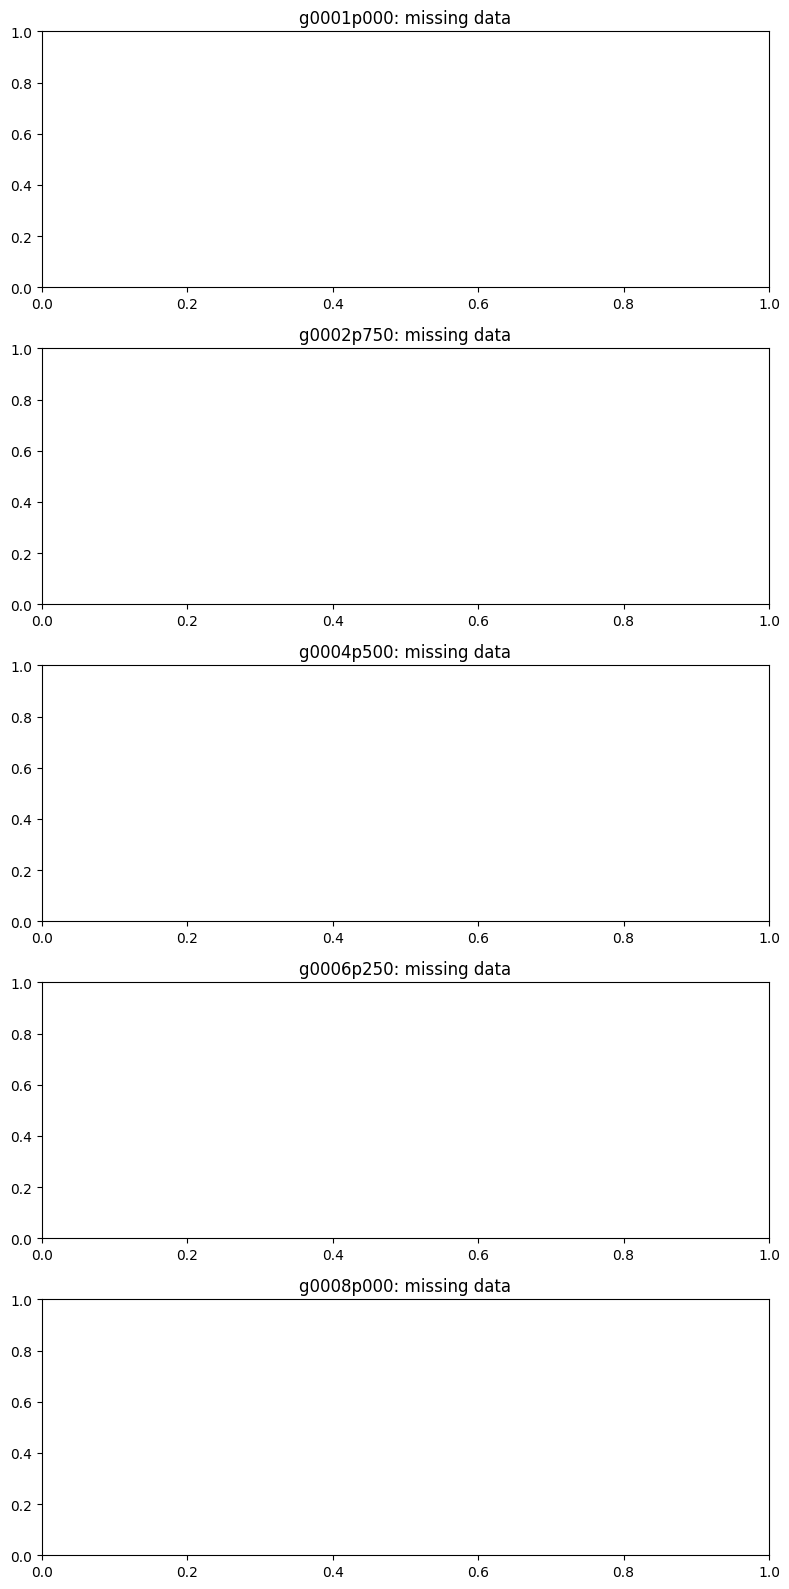

In [6]:
def rel_diff(ref_spec, new_spec, floor_frac=0.01):
    '''Relative difference restricted to bins where ref exceeds floor_frac of its peak.'''
    peak = np.abs(ref_spec).max()
    if peak == 0:
        return np.array([])
    mask = np.abs(ref_spec) >= floor_frac * peak
    if not mask.any():
        return np.array([])
    return (new_spec[mask] - ref_spec[mask]) / ref_spec[mask]


print(f"{'gamma_ij':>10}  {'cutoff i_t':>10}  {'max |rel diff|':>16}  {'mean |rel diff|':>16}")
print('-' * 58)

fig, axes = plt.subplots(len(manifest_rows), 1,
                         figsize=(8, 3.2 * len(manifest_rows)), sharex=False)
if len(manifest_rows) == 1:
    axes = [axes]

for row, ax in zip(manifest_rows, axes):
    name, gamma_ij = row['name'], row['gamma_ij']
    ref, new = reference[name], phase1[name]
    if ref is None or new is None:
        ax.set_title(f'{name}: missing data')
        continue

    for i_t in range(1, ref.spectrum.shape[0]):   # exclude cutoff 0 (noise-dominated)
        rd = rel_diff(ref.spectrum[i_t], new.spectrum[i_t])
        if rd.size:
            print(f'{gamma_ij:>10.4g}  {i_t:>10d}  '
                  f'{np.abs(rd).max()*100:>15.6g}%  {np.abs(rd).mean()*100:>15.6g}%')
        else:
            print(f'{gamma_ij:>10.4g}  {i_t:>10d}  {"(no bins above floor)":>16}')

    i_last = ref.spectrum.shape[0] - 1
    ax.plot(ref.w, ref.spectrum[i_last], color='C0', lw=2, label=f'ppw{GPU_FILON_PANELS_PER_OSC} reference')
    ax.plot(new.w, new.spectrum[i_last], color='C1', lw=1.5, ls='--',
            label=f'streaming (bs={DEFAULT_S_BATCH_SIZE})')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_title(f'gamma_ij={gamma_ij:.4g}, last cutoff (i_t={i_last})')
    ax.set_xlabel('w')
    ax.set_ylabel('spectrum')
    ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'gpu_streaming_phase1_validation.pdf', bbox_inches='tight')
plt.show()

## 6. Phase 2: batch-size independence + timing

No batch-size-scan log found yet.
Note: no finite positive data for this axes y-axis yet -- leaving it linear (results not loaded yet?).
Note: no finite positive data for this axes y-axis yet -- leaving it linear (results not loaded yet?).


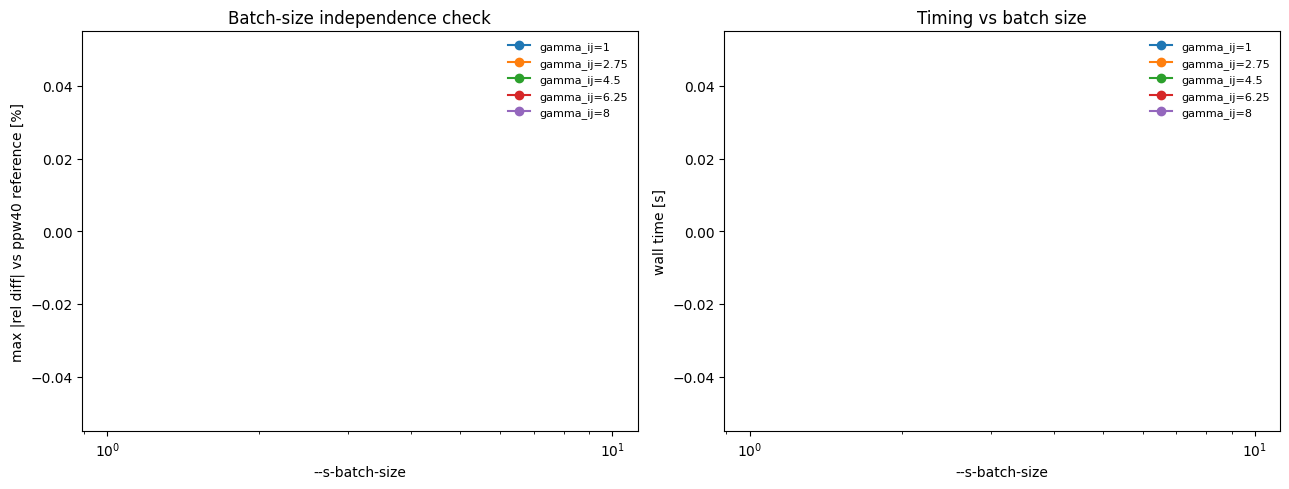

In [7]:
def parse_walltime_seconds(text_after_command):
    m = re.search(r'Elapsed \(wall clock\) time.*?:\s+(\S+)', text_after_command)
    if not m:
        return None
    parts = [float(x) for x in m.group(1).split(':')]
    if len(parts) == 2:
        return parts[0]*60 + parts[1]
    return parts[0]*3600 + parts[1]*60 + parts[2]


def parse_timed_blocks(log_path):
    '''Split a shared SLURM log into (command, elapsed_seconds) pairs.

    The 5 gamma_ij tasks run concurrently and each loops serially over every
    batch size, all writing to the SAME job-wide stdout -- so timing blocks
    from different tasks interleave unpredictably. Match each block by the
    actual command line /usr/bin/time prints (which includes the output
    directory, e.g. .../gpu_streaming_scan/bs64/g0008p000/) rather than
    relying on any assumed ordering.
    '''
    text = Path(log_path).read_text(errors='replace')
    blocks = []
    for chunk in text.split('\tCommand being timed: ')[1:]:
        cmd_line, _, rest = chunk.partition('\n')
        blocks.append((cmd_line.strip().strip('\"'), parse_walltime_seconds(rest)))
    return blocks


def latest_log(pattern):
    logs = sorted(LOGS_DIR.glob(pattern), key=lambda p: p.stat().st_mtime)
    return logs[-1] if logs else None


timing_by_name_bs = {row['name']: {} for row in manifest_rows}
bs_log = latest_log('bm_streaming_bsscan_*.out')
if bs_log is not None:
    for cmd, secs in parse_timed_blocks(bs_log):
        m = re.search(r'gpu_streaming_scan/bs(\d+)/([^/\"]+)/', cmd)
        if m and secs is not None:
            bs, name = int(m.group(1)), m.group(2)
            timing_by_name_bs.setdefault(name, {})[bs] = secs
    n_parsed = sum(len(v) for v in timing_by_name_bs.values())
    print(f'Parsed {n_parsed}/{len(manifest_rows)*len(BATCH_SIZE_SCAN)} '
          f'(gamma, batch_size) timings from {bs_log.name}')
else:
    print('No batch-size-scan log found yet.')


fig, (ax_diff, ax_time) = plt.subplots(1, 2, figsize=(13, 5))

for row in manifest_rows:
    name, gamma_ij = row['name'], row['gamma_ij']
    ref = reference[name]
    if ref is None:
        continue

    max_diffs, times_s = [], []
    for bs in BATCH_SIZE_SCAN:
        res = batch_scan[name][bs]
        if res is None:
            max_diffs.append(np.nan)
        else:
            all_rd = [rel_diff(ref.spectrum[i_t], res.spectrum[i_t])
                     for i_t in range(1, ref.spectrum.shape[0])]
            all_rd = np.concatenate([a for a in all_rd if a.size]) if any(a.size for a in all_rd) else np.array([])
            max_diffs.append(np.abs(all_rd).max() * 100 if all_rd.size else np.nan)
        times_s.append(timing_by_name_bs.get(name, {}).get(bs, np.nan))

    ax_diff.plot(BATCH_SIZE_SCAN, max_diffs, marker='o', label=f'gamma_ij={gamma_ij:.4g}')
    ax_time.plot(BATCH_SIZE_SCAN, times_s, marker='o', label=f'gamma_ij={gamma_ij:.4g}')

def _set_log_if_finite_positive(ax, axis, lines):
    """log-scale an axis only if it actually has positive finite data --
    otherwise (e.g. no cluster results loaded yet) matplotlib's LogLocator
    raises at draw time on all-NaN/empty data."""
    vals = np.concatenate([np.asarray(l.get_ydata() if axis == 'y' else l.get_xdata())
                           for l in lines]) if lines else np.array([])
    finite_positive = vals[np.isfinite(vals) & (vals > 0)]
    if finite_positive.size:
        (ax.set_yscale if axis == 'y' else ax.set_xscale)('log')
    else:
        print(f'Note: no finite positive data for {ax.get_title() or "this axes"} '
              f'{axis}-axis yet -- leaving it linear (results not loaded yet?).')


ax_diff.set_xscale('log')   # batch sizes are always positive -- safe unconditionally
_set_log_if_finite_positive(ax_diff, 'y', ax_diff.lines)
ax_diff.set_xlabel('--s-batch-size')
ax_diff.set_ylabel(f'max |rel diff| vs ppw{GPU_FILON_PANELS_PER_OSC} reference [%]')
ax_diff.set_title('Batch-size independence check')
ax_diff.legend(frameon=False, fontsize=8)

ax_time.set_xscale('log')   # batch sizes are always positive -- safe unconditionally
_set_log_if_finite_positive(ax_time, 'y', ax_time.lines)
ax_time.set_xlabel('--s-batch-size')
ax_time.set_ylabel('wall time [s]')
ax_time.set_title('Timing vs batch size')
ax_time.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'gpu_streaming_batch_size_scan.pdf', bbox_inches='tight')
plt.show()